# Bab 1 — Exploratory Data Analysis (EDA)
**Practical Statistics for Data Scientists, 2nd Edition** — Peter Bruce, Andrew Bruce & Peter Gedeck (O'Reilly, 2020)

1. Elemen data terstruktur
2. Data persegi panjang (rectangular data)
3. Estimasi lokasi (mean, median, dll.)
4. Estimasi variabilitas
5. Menjelajahi distribusi data
6. Data biner & kategorikal
7. Korelasi
8. Menjelajahi dua variabel atau lebih

In [1]:
!pip install wquantiles statsmodels

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles
import seaborn as sns
import matplotlib.pyplot as plt

DATA = 'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/'

## 1. Elemen Data Terstruktur

Data mentah (teks, gambar, sensor, klik) harus diubah dulu jadi **data terstruktur** supaya bisa dianalisis secara statistik. Dua jenis utama:

| Jenis | Sub-jenis | Contoh |
|---|---|---|
| **Numerik** | *Kontinu* — bisa bernilai berapa saja dalam rentang | suhu, durasi, kecepatan angin |
| | *Diskrit* — hanya bilangan bulat (hitungan) | jumlah kejadian, jumlah anak |
| **Kategorikal** | *Nominal* — kategori tanpa urutan | jenis TV, nama kota |
| | *Biner* — hanya dua nilai | 0/1, ya/tidak |
| | *Ordinal* — kategori yang punya urutan | rating 1–5, S/M/L |

**Kenapa tipe data penting?**
- Menentukan jenis visualisasi, analisis, dan model yang cocok.
- Membantu software mengoptimalkan penyimpanan dan komputasi.
- Di Python, kolom kategorikal bisa disimpan sebagai `pd.Categorical`, dan data ordinal bisa diberi urutan (`ordered=True`), sehingga library seperti scikit-learn memperlakukannya dengan benar.

In [3]:
# Contoh: data ordinal di pandas
ukuran = pd.Categorical(['M', 'S', 'L', 'M', 'S'], categories=['S', 'M', 'L'], ordered=True)
print(ukuran)
print('Ukuran terbesar:', ukuran.max())

['M', 'S', 'L', 'M', 'S']
Categories (3, object): ['S' < 'M' < 'L']
Ukuran terbesar: L


## 2. Data Persegi Panjang (Rectangular Data)

Bentuk data paling umum untuk analisis: tabel 2 dimensi — **baris = rekaman/observasi**, **kolom = fitur/variabel**. Di Python ini adalah `pandas.DataFrame`.

**Istilah yang sering muncul (dan sinonimnya):**
- **Feature** = atribut, input, prediktor, variabel.
- **Outcome** = variabel dependen, respons, target.
- **Record** = baris, kasus, observasi, sampel.

**Struktur data non-persegi panjang** juga ada:
- *Time series* — pengukuran berurutan dari variabel yang sama.
- *Spatial data* — data dengan koordinat/lokasi.
- *Graph/network* — hubungan antar entitas (jaringan sosial, rute).

> Catatan: di statistik, "sample" = kumpulan baris. Di machine learning/CS, "sample" kadang berarti satu baris. Hati-hati dengan perbedaan istilah ini.

In [4]:
state = pd.read_csv(DATA + 'state.csv')
state.head(8)   # Tabel 1-2 di buku

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE


## 3. Estimasi Lokasi

Langkah pertama memahami satu variabel: cari **"nilai tipikal"**-nya, yaitu di mana sebagian besar data berada.

### Mean (rata-rata)
$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

### Trimmed mean
Buang $p$ nilai terkecil dan terbesar dulu, baru dirata-rata. Contoh: di lomba loncat indah, skor juri tertinggi & terendah dibuang supaya satu juri tidak terlalu berpengaruh.
$$\bar{x}_{trim} = \frac{\sum_{i=p+1}^{n-p} x_{(i)}}{n-2p}$$

### Weighted mean (rata-rata berbobot)
$$\bar{x}_w = \frac{\sum_{i=1}^{n} w_i x_i}{\sum_{i=1}^{n} w_i}$$
Dipakai ketika:
- Sebagian data kurang andal → bobotnya dikecilkan.
- Data tidak mewakili populasi secara seimbang → kelompok yang kurang terwakili diberi bobot lebih besar.

### Median & estimasi robust
- **Median** = nilai tengah setelah data diurutkan. Tidak terpengaruh nilai ekstrem.
- **Outlier** = nilai yang sangat jauh dari mayoritas data. Belum tentu salah, tapi perlu dicek.
- Estimasi disebut **robust** jika tidak mudah terpengaruh outlier. Median dan trimmed mean termasuk robust; mean tidak.

**Poin kunci:** Mean adalah titik awal, tapi sensitif terhadap nilai ekstrem. Median dan trimmed mean lebih tahan terhadap outlier dan distribusi miring.

In [5]:
print('Mean populasi        :', state['Population'].mean())
print('Trimmed mean (10%)   :', trim_mean(state['Population'], 0.1))
print('Median populasi      :', state['Population'].median())

Mean populasi        : 6162876.3
Trimmed mean (10%)   : 4783697.125
Median populasi      : 4436369.5


Mean > trimmed mean > median → distribusi populasi **miring ke kanan** (ada beberapa negara bagian yang sangat besar, seperti California dan Texas).

Untuk tingkat pembunuhan (*murder rate*), rata-rata biasa memperlakukan tiap negara bagian sama. Agar mencerminkan rata-rata **per orang**, bobotnya pakai jumlah populasi:

In [6]:
print('Mean murder rate          :', state['Murder.Rate'].mean())
print('Weighted mean (populasi)  :', np.average(state['Murder.Rate'], weights=state['Population']))
print('Weighted median (populasi):', wquantiles.median(state['Murder.Rate'], weights=state['Population']))

Mean murder rate          : 4.066
Weighted mean (populasi)  : 4.445833981123393
Weighted median (populasi): 4.4


## 4. Estimasi Variabilitas

Lokasi saja tidak cukup. Dimensi kedua adalah **variabilitas (dispersi)**: apakah data berkumpul rapat atau menyebar?

### Berbasis deviasi
Deviasi = selisih nilai data dengan estimasi lokasi. Contoh data $\{1, 4, 4\}$: mean = 3, deviasi = $\{-2, 1, 1\}$ (jumlahnya selalu 0, makanya perlu diabsolutkan atau dikuadratkan).

- **Mean absolute deviation**
$$\text{MeanAD} = \frac{\sum |x_i - \bar{x}|}{n}$$
- **Varians**
$$s^2 = \frac{\sum (x_i - \bar{x})^2}{n-1}$$
- **Standar deviasi** — akar varians, satuannya sama dengan data asli.
$$s = \sqrt{s^2}$$

**Kenapa $n-1$ (degrees of freedom)?** Kalau pakai $n$, varians sampel cenderung *meremehkan* varians populasi (bias). Pembagi $n-1$ membuatnya tidak bias. Untuk data besar perbedaannya kecil.

- **Median absolute deviation (MAD)** — versi robust:
$$\text{MAD} = \text{median}(|x_i - m|)$$
dengan $m$ = median. Biasanya dikalikan faktor skala ($1/0.6745 \approx 1.4826$) supaya setara dengan standar deviasi pada distribusi normal.

### Berbasis persentil
- **Range** = maks − min → sangat sensitif outlier.
- **Persentil ke-P** = nilai di mana P% data berada di bawahnya.
- **Interquartile range (IQR)** = persentil 75 − persentil 25 → robust.

**Poin kunci:** Varians & standar deviasi paling populer, tapi sensitif outlier. MAD dan IQR lebih robust.

In [7]:
pop = state['Population']
print('Standar deviasi :', pop.std())
print('IQR             :', pop.quantile(0.75) - pop.quantile(0.25))
print('MAD (statsmodels):', robust.scale.mad(pop))
print('MAD (manual)     :', (pop - pop.median()).abs().median() / 0.6744897501960817)

Standar deviasi : 6848235.347401142
IQR             : 4847308.0
MAD (statsmodels): 3849876.1459979336
MAD (manual)     : 3849876.1459979336


Standar deviasi (~6,8 juta) hampir dua kali MAD (~3,8 juta) karena standar deviasi tertarik oleh beberapa negara bagian dengan populasi sangat besar.

## 5. Menjelajahi Distribusi Data

Estimasi tunggal meringkas data dengan satu angka. Untuk melihat **bentuk keseluruhan** distribusi, gunakan:

| Alat | Kegunaan |
|---|---|
| **Persentil / kuantil** | Ringkasan numerik, terutama untuk melihat ekor distribusi |
| **Boxplot** | Visual cepat berbasis kuartil; bagus membandingkan banyak kelompok |
| **Tabel frekuensi** | Hitungan data per interval (*bin*) |
| **Histogram** | Plot tabel frekuensi |
| **Density plot** | Versi halus histogram (kernel density estimate) |

### 5.1 Persentil dan Boxplot

In [8]:
p = [0.05, 0.25, 0.5, 0.75, 0.95]
df = pd.DataFrame(state['Murder.Rate'].quantile(p))
df.index = [f'{int(x*100)}%' for x in p]
df.T   # Tabel 1-4

,5%,25%,50%,75%,95%
Murder.Rate,1.6,2.425,4.0,5.55,6.51


**Cara membaca boxplot:**
- Kotak: dari kuartil 1 (Q1) sampai kuartil 3 (Q3) → tingginya = IQR.
- Garis di dalam kotak: median.
- *Whisker*: memanjang ke nilai terjauh yang masih dalam 1,5 × IQR dari tepi kotak.
- Titik di luar whisker: kandidat outlier.

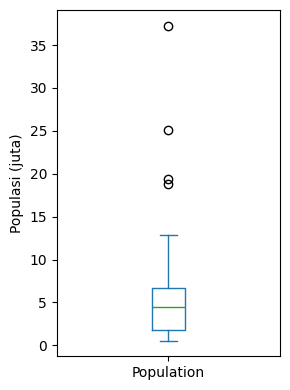

In [9]:
ax = (state['Population'] / 1_000_000).plot.box(figsize=(3, 4))
ax.set_ylabel('Populasi (juta)')
plt.tight_layout(); plt.show()

### 5.2 Tabel Frekuensi dan Histogram
Rentang data dibagi menjadi beberapa *bin* berukuran sama, lalu dihitung berapa data yang masuk tiap bin. Pemilihan jumlah bin penting: terlalu sedikit menyembunyikan pola, terlalu banyak membuat grafik "berisik".

In [10]:
binned = pd.cut(state['Population'], 10)
binned.value_counts(sort=False)

,count
Population,
"(526935.67, 4232659.0]",24
"(4232659.0, 7901692.0]",14
"(7901692.0, 11570725.0]",6
"(11570725.0, 15239758.0]",2
"(15239758.0, 18908791.0]",1
"(18908791.0, 22577824.0]",1
"(22577824.0, 26246857.0]",1
"(26246857.0, 29915890.0]",0
"(29915890.0, 33584923.0]",0


In [11]:
# Tabel 1-5: bin + daftar negara bagian di dalamnya
binned.name = 'binnedPopulation'
df = pd.concat([state, binned], axis=1).sort_values('Population')
groups = [{'BinRange': g, 'Count': len(s), 'States': ','.join(s.Abbreviation)}
          for g, s in df.groupby('binnedPopulation', observed=False)]
pd.DataFrame(groups)

,BinRange,Count,States
0,"(526935.67, 4232659.0]",24,"WY,VT,ND,AK,SD,DE,MT,RI,NH,ME,HI,ID,NE,WV,NM,N..."
1,"(4232659.0, 7901692.0]",14,"KY,LA,SC,AL,CO,MN,WI,MD,MO,TN,AZ,IN,MA,WA"
2,"(7901692.0, 11570725.0]",6,"VA,NJ,NC,GA,MI,OH"
3,"(11570725.0, 15239758.0]",2,"PA,IL"
4,"(15239758.0, 18908791.0]",1,FL
5,"(18908791.0, 22577824.0]",1,NY
6,"(22577824.0, 26246857.0]",1,TX
7,"(26246857.0, 29915890.0]",0,
8,"(29915890.0, 33584923.0]",0,
9,"(33584923.0, 37253956.0]",1,CA


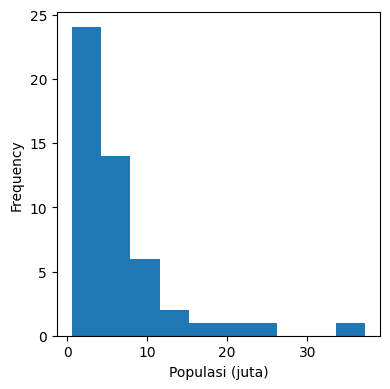

In [12]:
ax = (state['Population'] / 1_000_000).plot.hist(figsize=(4, 4))
ax.set_xlabel('Populasi (juta)')
plt.tight_layout(); plt.show()

Histogram di atas memperlihatkan distribusi yang **miring ke kanan** (*right-skewed*). Dua istilah bentuk distribusi dari buku:
- **Skewness** — kemiringan: apakah data lebih condong ke nilai kecil atau besar.
- **Kurtosis** — seberapa "tebal" ekornya, yaitu kecenderungan punya nilai ekstrem.

### 5.3 Density Plot
Density plot adalah garis halus yang mengestimasi distribusi, biasanya dengan **kernel density estimation (KDE)**:
$$\hat{f}(x) = \frac{1}{nh}\sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$
$h$ (*bandwidth*) mengatur kehalusan kurva. Sumbu-y density plot adalah **proporsi**, bukan hitungan, sehingga luas di bawah kurva = 1.

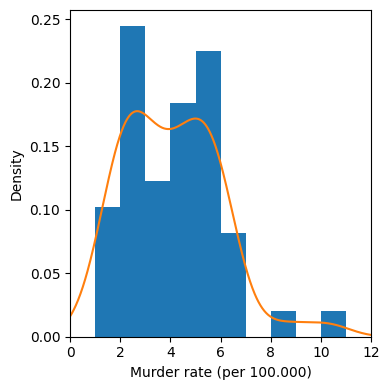

In [13]:
ax = state['Murder.Rate'].plot.hist(density=True, xlim=[0, 12], bins=range(1, 12), figsize=(4, 4))
state['Murder.Rate'].plot.density(ax=ax)
ax.set_xlabel('Murder rate (per 100.000)')
plt.tight_layout(); plt.show()

## 6. Data Biner dan Kategorikal

Untuk data kategorikal, ringkasan paling berguna biasanya **proporsi atau persentase** tiap kategori.

**Konsep kunci:**
- **Mode (modus)** — kategori/nilai yang paling sering muncul. Lebih relevan untuk data kategorikal daripada numerik.
- **Expected value** — rata-rata berbobot probabilitas. Contoh dari buku: layanan berlangganan dengan dua paket; nilai harapan per pengunjung = Σ (nilai × probabilitas):
$$EV = \sum_i x_i \, P(x_i)$$
Ini dipakai luas dalam valuasi bisnis dan penganggaran.
- **Probabilitas** — cara sederhana memahaminya: proporsi kejadian jika situasi diulang berkali-kali.

**Visualisasi:** bar chart (disarankan) atau pie chart (kurang disarankan karena sulit dibandingkan secara visual). Berbeda dengan histogram, sumbu-x bar chart berisi kategori, bukan angka kontinu.

Contoh: persentase penyebab keterlambatan penerbangan di Bandara Dallas/Fort Worth.

In [14]:
dfw = pd.read_csv(DATA + 'dfw_airline.csv')
print(100 * dfw / dfw.values.sum())   # persentase tiap penyebab

     Carrier        ATC   Weather  Security    Inbound
0  23.022989  30.400781  4.025214  0.122937  42.428079


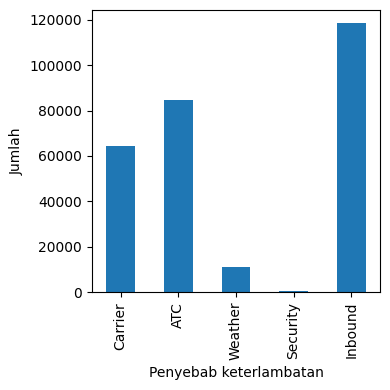

In [15]:
ax = dfw.transpose().plot.bar(figsize=(4, 4), legend=False)
ax.set_xlabel('Penyebab keterlambatan')
ax.set_ylabel('Jumlah')
plt.tight_layout(); plt.show()

In [16]:
# Contoh expected value (skenario dari buku):
# 5% pengunjung ambil paket $300/bulan, 15% ambil paket $50/bulan, 80% tidak berlangganan
EV = 0.05 * 300 + 0.15 * 50 + 0.80 * 0
print(f'Expected value per pengunjung: ${EV}/bulan')

Expected value per pengunjung: $22.5/bulan


## 7. Korelasi

Korelasi mengukur seberapa kuat dua variabel numerik bergerak bersama.
- **Korelasi positif**: X naik → Y cenderung naik.
- **Korelasi negatif**: X naik → Y cenderung turun.

**Koefisien korelasi Pearson:**
$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{(n-1)\, s_x s_y}$$
Nilainya selalu antara −1 dan +1; 0 berarti tidak ada hubungan **linear**.

**Hal penting:**
- Pearson hanya menangkap hubungan **linear**. Hubungan non-linear bisa saja kuat tapi $r$ mendekati 0.
- Sensitif terhadap outlier. Alternatif robust: **Spearman's rho** dan **Kendall's tau** (berbasis ranking).
- **Matriks korelasi** berguna untuk melihat hubungan banyak variabel sekaligus, dan bisa divisualisasikan sebagai heatmap.
- **Scatterplot** adalah cara standar memvisualisasikan hubungan dua variabel.

Contoh: return harian saham dan ETF (S&P 500).

In [17]:
sp500_sym = pd.read_csv(DATA + 'sp500_sectors.csv')
sp500_px = pd.read_csv(DATA + 'sp500_data.csv.gz', index_col=0)

# Saham sektor telekomunikasi sejak Juli 2012
telecom_sym = sp500_sym[sp500_sym['sector'] == 'telecommunications_services']['symbol']
telecom = sp500_px.loc[sp500_px.index >= '2012-07-01', telecom_sym]
telecom.corr()   # Tabel 1-7

,T,CTL,FTR,VZ,LVLT
T,1.000000,0.474683,0.327767,0.677612,0.278626
CTL,0.474683,1.000000,0.419757,0.416604,0.286665
FTR,0.327767,0.419757,1.000000,0.287386,0.260068
VZ,0.677612,0.416604,0.287386,1.000000,0.242199
LVLT,0.278626,0.286665,0.260068,0.242199,1.000000


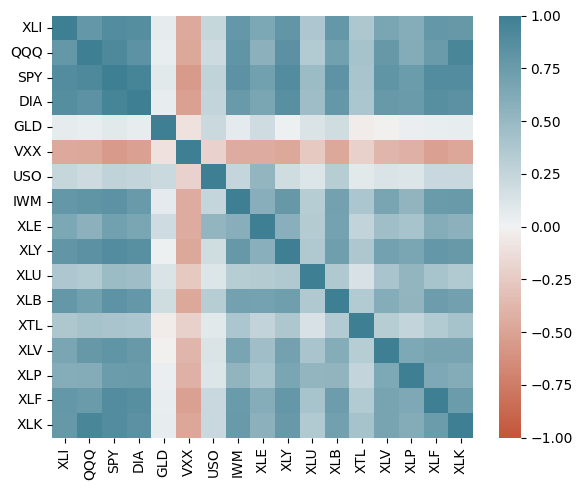

In [18]:
# Heatmap korelasi ETF (versi Figure 1-6)
etfs = sp500_px.loc[sp500_px.index > '2012-07-01',
                    sp500_sym[sp500_sym['sector'] == 'etf']['symbol']]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(etfs.corr(), vmin=-1, vmax=1, cmap=sns.diverging_palette(20, 220, as_cmap=True), ax=ax)
plt.tight_layout(); plt.show()

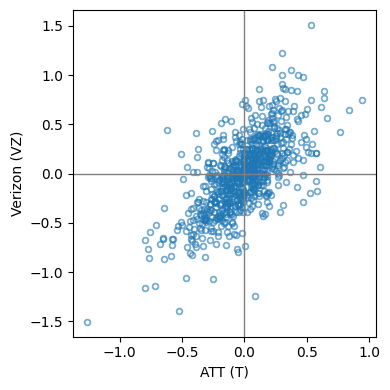

In [19]:
# Scatterplot return harian ATT (T) vs Verizon (VZ) — Figure 1-7
ax = telecom.plot.scatter(x='T', y='VZ', figsize=(4, 4), marker='$\u25EF$', alpha=0.5)
ax.set_xlabel('ATT (T)'); ax.set_ylabel('Verizon (VZ)')
ax.axhline(0, color='grey', lw=1); ax.axvline(0, color='grey', lw=1)
plt.tight_layout(); plt.show()

In [20]:
# Pearson vs Spearman
print('Pearson :', telecom['T'].corr(telecom['VZ']))
print('Spearman:', telecom['T'].corr(telecom['VZ'], method='spearman'))

Pearson : 0.6776124610128049
Spearman: 0.6649847837751102


## 8. Menjelajahi Dua Variabel atau Lebih

Estimasi sebelumnya bersifat **univariat** (satu variabel). Bagian ini membahas analisis **bivariat** dan **multivariat**.

| Kombinasi variabel | Alat visualisasi / ringkasan |
|---|---|
| Numerik vs numerik (data besar) | **Hexagonal binning**, **contour plot**, heatmap |
| Kategorikal vs kategorikal | **Contingency table** (tabel silang) |
| Numerik vs kategorikal | **Boxplot per kelompok**, **violin plot** |
| Lebih dari dua variabel | **Conditioning / faceting** (panel per kelompok) |

### 8.1 Hexagonal Binning dan Contour
Scatterplot jadi sulit dibaca kalau datanya ratusan ribu titik (tumpang tindih). Solusinya, kelompokkan titik ke dalam heksagon dan beri warna sesuai jumlahnya.

Contoh: nilai properti vs luas bangunan di King County, Washington.

(432693, 3)


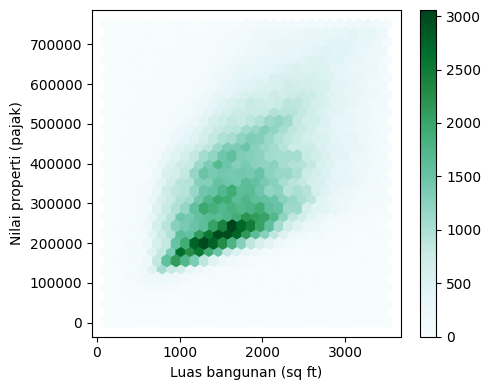

In [21]:
kc_tax = pd.read_csv(DATA + 'kc_tax.csv.gz')
kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                     (kc_tax.SqFtTotLiving > 100) &
                     (kc_tax.SqFtTotLiving < 3500), :]
print(kc_tax0.shape)

ax = kc_tax0.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue', gridsize=30, sharex=False, figsize=(5, 4))
ax.set_xlabel('Luas bangunan (sq ft)'); ax.set_ylabel('Nilai properti (pajak)')
plt.tight_layout(); plt.show()

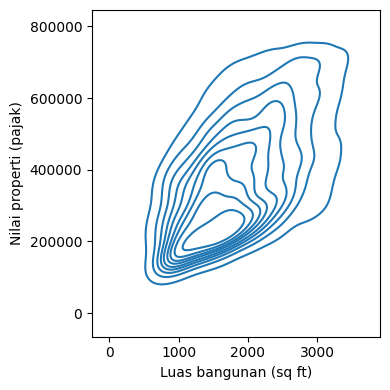

In [22]:
# Contour plot (KDE 2 dimensi) — pakai sampel supaya cepat
sample = kc_tax0.sample(10000, random_state=1)
fig, ax = plt.subplots(figsize=(4, 4))
sns.kdeplot(data=sample, x='SqFtTotLiving', y='TaxAssessedValue', ax=ax)
ax.set_xlabel('Luas bangunan (sq ft)'); ax.set_ylabel('Nilai properti (pajak)')
plt.tight_layout(); plt.show()

### 8.2 Dua Variabel Kategorikal: Contingency Table
Tabel silang menghitung jumlah (atau persentase) untuk setiap kombinasi kategori. Contoh: grade pinjaman vs status pinjaman (LendingClub).

In [23]:
lc_loans = pd.read_csv(DATA + 'lc_loans.csv')
crosstab = lc_loans.pivot_table(index='grade', columns='status', aggfunc=lambda x: len(x), margins=True)

# Ubah jadi proporsi per baris (Tabel 1-8)
df = crosstab.copy().loc['A':'G', :].astype(float)
df.loc[:, 'Charged Off':'Late'] = df.loc[:, 'Charged Off':'Late'].div(df['All'], axis=0)
df['All'] = df['All'] / sum(df['All'])
df.round(3)

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,0.022,0.690,0.282,0.006,0.161
B,0.040,0.709,0.235,0.016,0.294
C,0.050,0.736,0.191,0.023,0.268
D,0.067,0.717,0.184,0.031,0.165
E,0.082,0.708,0.171,0.039,0.077
F,0.118,0.654,0.180,0.047,0.029
G,0.126,0.614,0.198,0.061,0.007


### 8.3 Data Kategorikal dan Numerik: Boxplot & Violin Plot
Boxplot per kelompok memudahkan membandingkan distribusi antar kategori. **Violin plot** menambahkan bentuk density di kiri-kanan, sehingga terlihat detail distribusi yang tidak tampak di boxplot (misalnya distribusi bimodal). Kekurangannya, outlier kurang menonjol.

Contoh: persentase penerbangan yang terlambat karena maskapai (*carrier*), per maskapai.

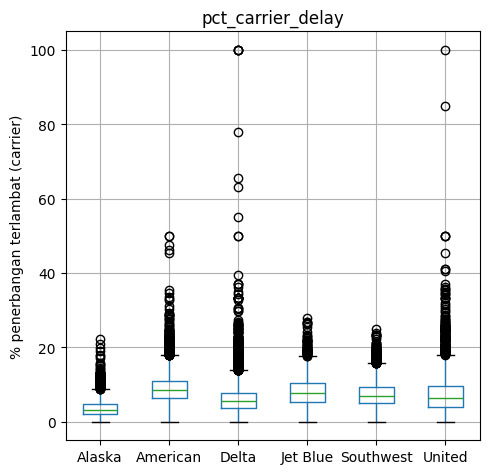

In [24]:
airline_stats = pd.read_csv(DATA + 'airline_stats.csv')
ax = airline_stats.boxplot(by='airline', column='pct_carrier_delay', figsize=(5, 5))
ax.set_xlabel(''); ax.set_ylabel('% penerbangan terlambat (carrier)')
plt.suptitle('')
plt.tight_layout(); plt.show()

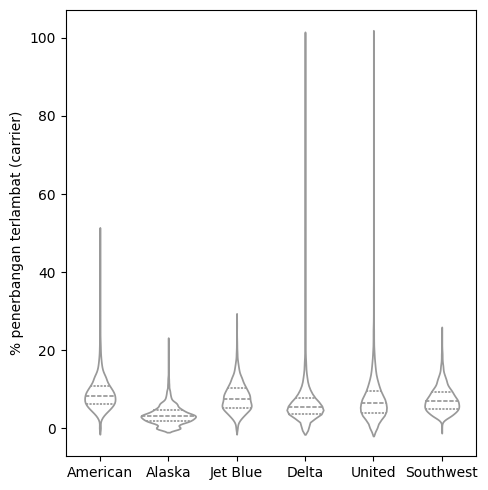

In [25]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay', ax=ax, inner='quartile', color='white')
ax.set_xlabel(''); ax.set_ylabel('% penerbangan terlambat (carrier)')
plt.tight_layout(); plt.show()

### 8.4 Visualisasi Banyak Variabel: Conditioning (Faceting)
Tambahkan variabel ketiga dengan cara **memecah plot per kelompok** (panel terpisah). Contoh: hexbin nilai properti vs luas bangunan, dipisah per kode pos. Terlihat bahwa hubungan luas–nilai berbeda antar wilayah.

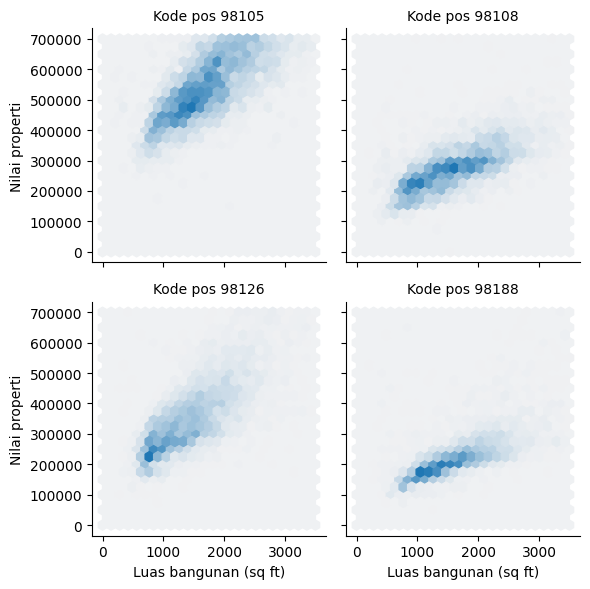

In [26]:
zip_codes = [98188, 98105, 98108, 98126]
kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes), :]

def hexbin(x, y, color, **kwargs):
    cmap = sns.light_palette(color, as_cmap=True)
    plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2)
g.map(hexbin, 'SqFtTotLiving', 'TaxAssessedValue', extent=[0, 3500, 0, 700000])
g.set_axis_labels('Luas bangunan (sq ft)', 'Nilai properti')
g.set_titles('Kode pos {col_name:.0f}')
plt.tight_layout(); plt.show()

## Ringkasan Bab 1

- **EDA** (dipopulerkan John Tukey, 1977) adalah langkah pertama setiap proyek data science: pahami data sebelum memodelkannya.
- Kenali **tipe data** (numerik kontinu/diskrit, kategorikal nominal/biner/ordinal) karena ini menentukan analisis yang tepat.
- **Estimasi lokasi**: mean (sensitif outlier), trimmed mean dan median (robust), weighted mean/median untuk data berbobot.
- **Estimasi variabilitas**: varians & standar deviasi (sensitif outlier), MAD & IQR (robust).
- **Distribusi**: persentil, boxplot, tabel frekuensi, histogram, density plot.
- **Data kategorikal**: proporsi, mode, expected value, bar chart.
- **Korelasi**: Pearson untuk hubungan linear; Spearman/Kendall untuk versi robust berbasis ranking; visualisasi dengan scatterplot & heatmap.
- **Multivariat**: hexbin/contour untuk data numerik besar, contingency table untuk kategorikal, boxplot/violin untuk campuran, faceting untuk variabel tambahan.

Pesan utama bab ini: **ringkasan sederhana dan visualisasi sering sudah cukup untuk menemukan banyak insight**, dan metode yang robust penting karena data dunia nyata jarang "bersih".